# EDA on battles_cards.csv

## Setup

In [1]:
# IMPORTS
import pandas as pd

In [2]:
import os
os.chdir("/Users/kevinhu/Programming/clash_predict")

In [3]:
# Read CSV
df = pd.read_csv('data/processed/battles_cards.csv')
df.head(10)

,team_trophies,opp_trophies,trophy_diff,team_avg_elixir,opp_avg_elixir,team_norm_level_Archer_Queen,team_norm_level_Archers,team_norm_level_Arrows,team_norm_level_Baby_Dragon,team_norm_level_Balloon,...,team_support_count,opp_win_condition_count,opp_spell_count,opp_air_count,opp_mini-tank_count,opp_building_count,opp_swarm_count,opp_cycle_count,opp_support_count,label
0,9000,9000,0,2.875,3.750,0.0,0.875,0.0,0.0,0.0,...,1,2,2,0,3,0,1,2,1,1
1,9000,8970,30,2.875,3.375,0.0,0.875,0.0,0.0,0.0,...,1,1,2,0,2,0,2,0,2,1
2,8996,8993,3,2.875,3.750,0.0,0.875,0.0,0.0,0.0,...,1,0,2,0,2,0,1,2,3,1
3,8966,8977,-11,2.875,3.625,0.0,0.875,0.0,0.0,0.0,...,1,1,3,2,3,0,0,1,2,1
4,8933,8970,-37,2.875,3.375,0.0,0.875,0.0,0.0,0.0,...,1,0,1,0,2,1,0,3,5,1
5,8963,8963,0,2.875,4.500,0.0,0.875,0.0,0.0,0.0,...,1,1,2,2,3,1,0,1,3,0
6,8933,8933,0,2.875,4.125,0.0,0.875,0.0,0.0,0.0,...,1,2,3,2,2,0,0,1,2,1
7,8964,8942,22,2.875,3.625,0.0,0.875,0.0,0.0,0.0,...,1,0,1,0,2,1,1,1,3,0
8,8936,8923,13,2.875,3.375,0.0,0.875,0.0,0.0,0.0,...,1,1,1,0,2,1,2,2,1,1
9,8906,8906,0,2.875,3.875,0.0,0.875,0.0,0.0,0.0,...,1,1,3,3,1,0,0,1,2,1


In [4]:
# View all columns
print("Columns:", df.columns.tolist())
print("\nTotal columns:", len(df.columns))

Columns: ['team_trophies', 'opp_trophies', 'trophy_diff', 'team_avg_elixir', 'opp_avg_elixir', 'team_norm_level_Archer_Queen', 'team_norm_level_Archers', 'team_norm_level_Arrows', 'team_norm_level_Baby_Dragon', 'team_norm_level_Balloon', 'team_norm_level_Bandit', 'team_norm_level_Barbarian_Barrel', 'team_norm_level_Barbarian_Hut', 'team_norm_level_Barbarians', 'team_norm_level_Bats', 'team_norm_level_Battle_Healer', 'team_norm_level_Battle_Ram', 'team_norm_level_Berserker', 'team_norm_level_Bomb_Tower', 'team_norm_level_Bomber', 'team_norm_level_Boss_Bandit', 'team_norm_level_Bowler', 'team_norm_level_Cannon', 'team_norm_level_Cannon_Cart', 'team_norm_level_Clone', 'team_norm_level_Dark_Prince', 'team_norm_level_Dart_Goblin', 'team_norm_level_Earthquake', 'team_norm_level_Electro_Dragon', 'team_norm_level_Electro_Giant', 'team_norm_level_Electro_Spirit', 'team_norm_level_Electro_Wizard', 'team_norm_level_Elite_Barbarians', 'team_norm_level_Elixir_Collector', 'team_norm_level_Elixir_Gol

## Basics

In [5]:
# Shape
print("Shape: ", df.shape)


Shape:  (49284, 272)


In [6]:
# Class balance
print('Label distribution: ', df['label'].value_counts())

Label distribution:  label
1    27173
0    22111
Name: count, dtype: int64


In [7]:
# Missing Values
print('Missing Values: ', df.isnull().sum())

Missing Values:  team_trophies         0
opp_trophies          0
trophy_diff           0
team_avg_elixir       0
opp_avg_elixir        0
                     ..
opp_building_count    0
opp_swarm_count       0
opp_cycle_count       0
opp_support_count     0
label                 0
Length: 272, dtype: int64


In [8]:
# Basic stats on numeric cols
numeric_cols = ["team_trophies", "opp_trophies", "trophy_diff", "team_avg_elixir", "opp_avg_elixir"]
print('Numeric stats: ', df[numeric_cols].describe())

Numeric stats:         team_trophies  opp_trophies   trophy_diff  team_avg_elixir  \
count   49284.000000  49284.000000  49284.000000     49284.000000   
mean     7474.297926   7474.787842     -0.489916         3.724236   
std      1307.438109   1307.434867     17.227858         0.505165   
min      3000.000000   3000.000000    -55.000000         1.125000   
25%      6500.000000   6503.000000     -9.000000         3.375000   
50%      7726.000000   7729.000000      0.000000         3.750000   
75%      8680.000000   8680.000000      7.000000         4.000000   
max      9000.000000   9048.000000     56.000000         7.125000   

       opp_avg_elixir  
count    49284.000000  
mean         3.735571  
std          0.526531  
min          1.250000  
25%          3.375000  
50%          3.750000  
75%          4.000000  
max          7.250000  


In [9]:
# Opponents with over 10000 trophies
print(df[df['opp_trophies'] > 10000][['team_trophies', 'opp_trophies', 'trophy_diff']].head(20))

Empty DataFrame
Columns: [team_trophies, opp_trophies, trophy_diff]
Index: []


## Card Features

In [10]:
# How often does each card appear in team decks? (norm_level > 0 means card is present)
team_card_cols = [c for c in df.columns if c.startswith("team_norm_level_")]
card_presence = (df[team_card_cols] > 0).sum().sort_values(ascending=False)
card_presence.index = [c.replace("team_norm_level_", "") for c in card_presence.index]
print("Most common team cards:\n", card_presence.head(15))
print("\nLeast common team cards:\n", card_presence.tail(15))

Most common team cards:
 Witch             21672
Mini_P.E.K.K.A    17021
The_Log           16733
Skeleton_Army     16073
Mega_Knight       15194
Knight            13334
Valkyrie          13049
Goblin_Barrel     12648
Hog_Rider         10781
Wizard             9874
Arrows             9533
Fireball           8244
Firecracker        7954
Zap                7248
Golden_Knight      6979
dtype: int64

Least common team cards:
 Mortar               352
Goblin_Giant         324
Void                 305
Flying_Machine       274
Three_Musketeers     244
Goblin_Drill         229
Heal_Spirit          214
Goblin_Demolisher    212
Phoenix              210
Lava_Hound           175
Spirit_Empress       167
Goblin_Machine       147
Cannon_Cart          107
Rune_Giant            45
Barbarian_Hut         35
dtype: int64


In [11]:
# How often does each opp card appear?
opp_card_cols = [c for c in df.columns if c.startswith("opp_norm_level_")]
opp_presence = (df[opp_card_cols] > 0).sum().sort_values(ascending=False)
opp_presence.index = [c.replace("opp_norm_level_", "") for c in opp_presence.index]
print("Most common opp cards:\n", opp_presence.head(15))
print("\nLeast common opp cards:\n", opp_presence.tail(15))

Most common opp cards:
 Witch               18373
Mini_P.E.K.K.A      15064
Skeleton_Army       14183
The_Log             14160
Mega_Knight         13128
Knight              11824
Arrows              11368
Valkyrie            10973
Goblin_Barrel       10504
Hog_Rider            8302
Zap                  7989
Wizard               7601
Fireball             7567
Barbarian_Barrel     7384
Firecracker          6992
dtype: int64

Least common opp cards:
 Goblin_Machine       501
Suspicious_Bush      440
Three_Musketeers     410
Goblinstein          379
Earthquake           337
Mortar               322
Monk                 265
Goblin_Drill         232
Spirit_Empress       222
Phoenix              189
Cannon_Cart          179
Void                 173
Goblin_Demolisher    149
Barbarian_Hut         49
Rune_Giant            45
dtype: int64


### Drop Card Features that Appear Less than 1%

In [12]:
# Team cards with low frequency (< 1% of battles)
low_freq_team = [c for c in team_card_cols if (df[c] > 0).sum() < (df.shape[0] * 0.01)]
print(f"Low frequency team cards to drop: {len(low_freq_team)}")
for c in low_freq_team:
    print(f"  {c.replace('team_norm_level_', '')}: {(df[c] > 0).sum()}")

Low frequency team cards to drop: 23
  Barbarian_Hut: 35
  Battle_Healer: 394
  Cannon_Cart: 107
  Earthquake: 416
  Elixir_Collector: 451
  Flying_Machine: 274
  Goblin_Demolisher: 212
  Goblin_Drill: 229
  Goblin_Giant: 324
  Goblin_Machine: 147
  Goblinstein: 424
  Heal_Spirit: 214
  Lava_Hound: 175
  Monk: 353
  Mortar: 352
  Night_Witch: 437
  Phoenix: 210
  Rascals: 399
  Rune_Giant: 45
  Skeleton_Dragons: 447
  Spirit_Empress: 167
  Three_Musketeers: 244
  Void: 305


In [13]:
# Opp cards with low frequency (< 1% of battles)
low_freq_opp = [c for c in opp_card_cols if (df[c] > 0).sum() < (df.shape[0] * 0.01)]
print(f"Low frequency opp cards to drop: {len(low_freq_opp)}")
for c in low_freq_opp:
    print(f"  {c.replace('opp_norm_level_', '')}: {(df[c] > 0).sum()}")

Low frequency opp cards to drop: 14
  Barbarian_Hut: 49
  Cannon_Cart: 179
  Earthquake: 337
  Goblin_Demolisher: 149
  Goblin_Drill: 232
  Goblinstein: 379
  Monk: 265
  Mortar: 322
  Phoenix: 189
  Rune_Giant: 45
  Spirit_Empress: 222
  Suspicious_Bush: 440
  Three_Musketeers: 410
  Void: 173


## Deck Balance Features

In [19]:
# Deck balance role counts - team
team_balance_cols = [c for c in df.columns if c.startswith("team_") and c.endswith("_count")]
print("Team deck role distributions:\n")
print(df[team_balance_cols].describe().round(2))

Team deck role distributions:

       team_win_condition_count  team_spell_count  team_air_count  \
count                  49284.00          49284.00        49284.00   
mean                       1.23              1.65            0.48   
std                        0.78              0.86            0.66   
min                        0.00              0.00            0.00   
25%                        1.00              1.00            0.00   
50%                        1.00              2.00            0.00   
75%                        2.00              2.00            1.00   
max                        6.00              7.00            4.00   

       team_mini-tank_count  team_building_count  team_swarm_count  \
count              49284.00             49284.00          49284.00   
mean                   2.20                 0.48              0.94   
std                    0.98                 0.55              0.76   
min                    0.00                 0.00              0.00 

In [15]:
# Deck balance role counts - opponent
opp_balance_cols = [c for c in df.columns if c.startswith("opp_") and c.endswith("_count")]
print("Opp deck role distributions:\n")
print(df[opp_balance_cols].describe().round(2))

Opp deck role distributions:

       opp_win_condition_count  opp_spell_count  opp_air_count  \
count                 49284.00         49284.00       49284.00   
mean                      1.29             1.75           0.59   
std                       0.77             0.88           0.78   
min                       0.00             0.00           0.00   
25%                       1.00             1.00           0.00   
50%                       1.00             2.00           0.00   
75%                       2.00             2.00           1.00   
max                       6.00             8.00           7.00   

       opp_mini-tank_count  opp_building_count  opp_swarm_count  \
count             49284.00            49284.00         49284.00   
mean                  2.18                0.48             0.89   
std                   1.00                0.55             0.79   
min                   0.00                0.00             0.00   
25%                   1.00              

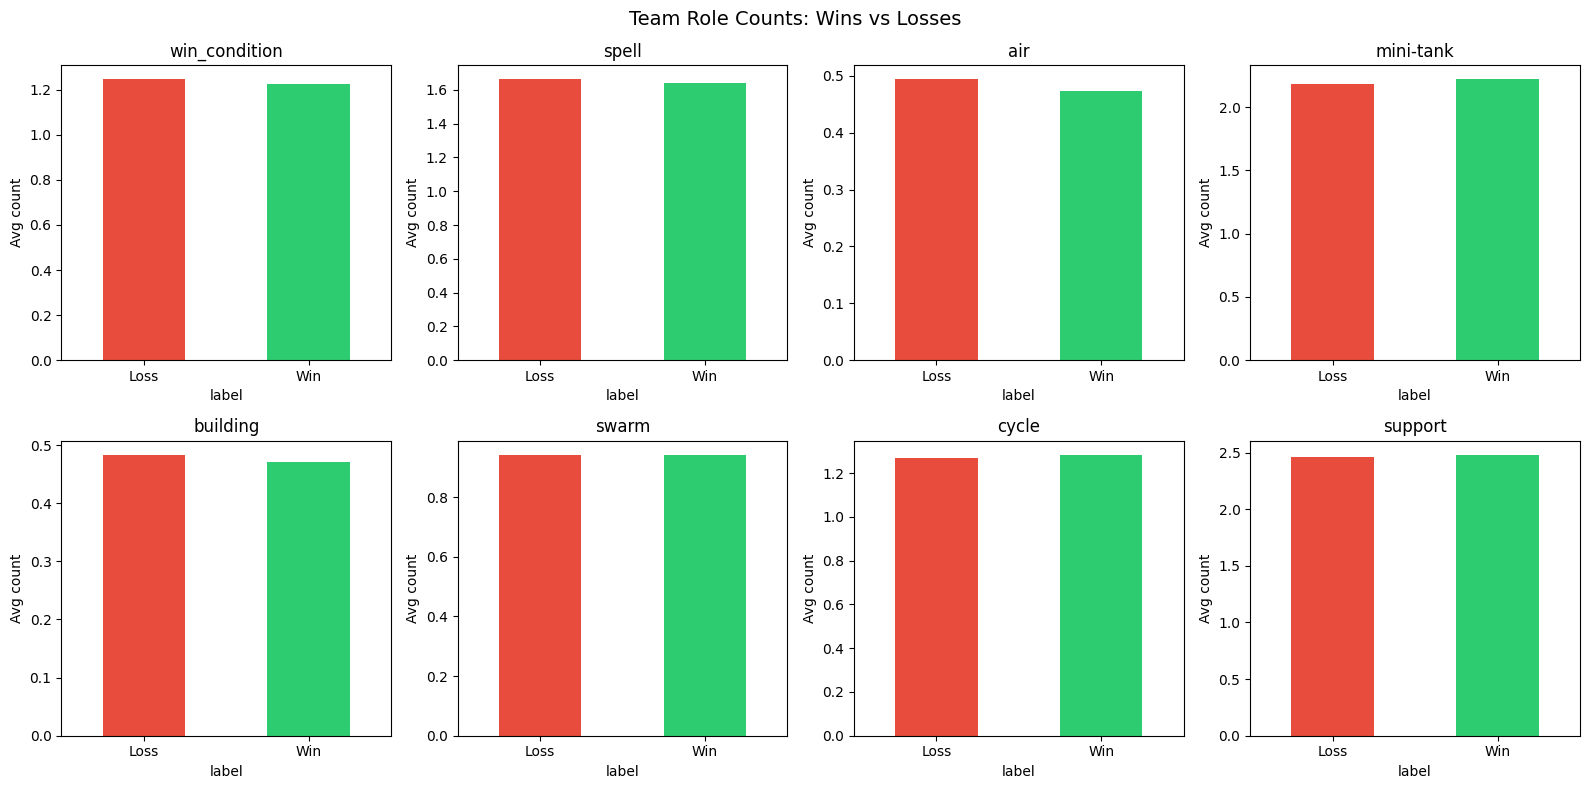

In [20]:
# Compare role counts between wins and losses
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Team Role Counts: Wins vs Losses", fontsize=14)

for ax, col in zip(axes.flatten(), team_balance_cols):
    role_name = col.replace("team_", "").replace("_count", "")
    df.groupby("label")[col].mean().plot(kind="bar", ax=ax, color=["#e74c3c", "#2ecc71"])
    ax.set_title(role_name)
    ax.set_xticklabels(["Loss", "Win"], rotation=0)
    ax.set_ylabel("Avg count")

plt.tight_layout()
plt.show()

## MUST RUN THIS TO SAVE

In [17]:
# Drop low frequency columns and save
drop_cols = low_freq_team + low_freq_opp
df_clean = df.drop(columns=drop_cols)
print(f"Dropped {len(drop_cols)} low-frequency columns")
print(f"Final shape: {df_clean.shape}")
df_clean.to_csv("data/processed/battles_cards_cleaned.csv", index=False)

Dropped 37 low-frequency columns
Final shape: (49284, 235)


# XGBoost Model

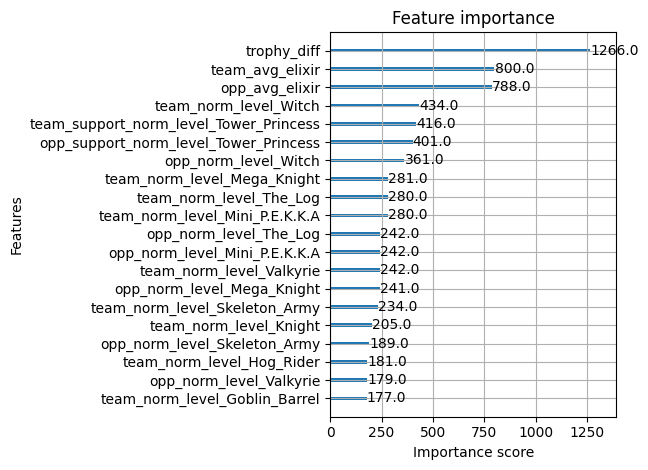

In [18]:
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt

model = joblib.load("models/xgb_clash_model.joblib")
xgb.plot_importance(model, max_num_features=20)
plt.tight_layout()
plt.show()